<a href="https://colab.research.google.com/github/sandramohan0311/Construction/blob/main/star_and_galaxy_classification_using_bayesian_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install livelossplot

In [ ]:
import os
import cv2
import h5py
from livelossplot import PlotLossesKeras
import tensorflow_probability as tfp
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import RMSprop, Adam
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn import metrics
from math import ceil, floor
import seaborn as sns
from tqdm import tqdm
import numpy as np
import pandas as pd
import random
import json

In [ ]:
tfd = tfp.distributions
tfpl = tfp.layers


total_samples = 5081
train_samples = floor(total_samples*0.7)
val_samples = ceil(total_samples*0.15)
test_samples = total_samples - train_samples - val_samples
batch_size = 64
epochs = 50
weights_dir = {
    'frequentist' : './checkpoints/freq_logs/best' ,
    'bayesian' : './checkpoints/baye_logs/best'
}
ensemble_size = 50

In [ ]:
def plot_sample_with_confidence(sample_index=None, images=None, labels=None, ensemble_size=None, mode=None, style=None, model=None):
    """
    Plot a sample image along with the confidence (or uncertainty) estimated by a Bayesian neural network model.

    Args:
    - sample_index: Index of the sample to plot.
    - images: Array of input images.
    - labels: Array of true labels.
    - ensemble_size: Number of models in the ensemble.
    - mode: Indicates the data mode ('removed' or 'original').
    - style: Indicates the model style ('bayesian' or 'frequentist').
    - model: Trained model instance.

    Returns:
    - None (Displays the plot).
    """
    if model is None:
        raise ValueError("Model must be provided.")

    # Get the sample image and true label
    sample_image = images[sample_index]

    if labels is not None:
        true_label = np.argmax(labels[sample_index]) if mode == 'removed' else labels[sample_index]
    else:
        true_label = None

    # Initialize an array to store the predicted probabilities for each class
    predicted_probabilities = np.zeros((ensemble_size, model.output_shape[-1]))

    # Make predictions using each Bayesian network
    for i in range(ensemble_size):
        predicted_probabilities[i] = model.predict(sample_image.reshape(1, *sample_image.shape))

    # Calculate percentiles
    pct_2p5 = np.percentile(predicted_probabilities, 2.5, axis=0)
    pct_97p5 = np.percentile(predicted_probabilities, 97.5, axis=0)

    # Calculate mean probabilities and entropy
    mean_probabilities = np.mean(predicted_probabilities, axis=0)
    entropies = -np.sum(predicted_probabilities * np.log2(predicted_probabilities + 1e-10), axis=1)
    mean_entropy = np.mean(entropies)

    # Plot the sample image and confidence intervals
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(sample_image)
    plt.axis('off')
    plt.title(f'Sample Image\nTrue Label: {true_label}')

    plt.subplot(1, 2, 2)
    x = np.arange(model.output_shape[-1])
    colours = 'green'
    bars = plt.bar(x, mean_probabilities, color=colours, alpha=0.5, yerr=[mean_probabilities - pct_2p5, pct_97p5 - mean_probabilities])
    plt.xticks(x, [str(i) for i in range(model.output_shape[-1])])
    plt.xlabel('Classes')
    plt.ylabel('Probability')
    plt.title('Sample Classification with 95% CI (Bayesian)')
    plt.text(0.05, 0.95, f'Mean Entropy: {mean_entropy:.2f}', transform=plt.gca().transAxes, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

    plt.tight_layout()
    plt.show()



In [ ]:
def convert_to_categorical(labels=None):
    """
    Converts the labels to categorical.
    """
    if labels is None:
        raise ValueError("Labels must be provided.")

    one_hot_labels = []
    for label in labels:
        if label == 0:
            one_hot_labels.append([1, 0, 0])  # Class 0
        elif label == 1:
            one_hot_labels.append([0, 1, 0])  # Class 1
        elif label == 2:
            one_hot_labels.append([0, 0, 1])  # Class 2
        else:
            raise ValueError("Labels should be either 0 or 1 for binary classification.")

    return np.array(one_hot_labels).astype('float32')



In [ ]:
def create_hdf5_file(images = None, labels = None, mode = None):
    """
    Creates HDF5 file from the given images and labels.
    """
    if images is None or labels is None or mode is None:
        raise ValueError("Images, labels and mode must be provided.")
    else:
        # Create the HDF5 file
        samples = images.shape[0]
        labels_dim = labels.shape[1]
        image_size = images.shape[1]
        channels = images.shape[3]
        file = h5py.File(f'{mode}.hdf5', 'w')
        images_set, labels_set =  file.create_dataset(
            'images',
            (samples, image_size, image_size, channels),
            dtype='f4'
        ), file.create_dataset(
            'labels',
            (samples, labels_dim),
            dtype='f4'
        )
        # Write the images and labels to the HDF5 file
        images_set[...] = images
        labels_set[...] = labels
        file.close()

def HDF5ImageGenerator(hdf5_x = None, hdf5_y = None, batch_size = None, mode = 'train'):
    sample_count  = hdf5_x.shape[0]

    while True:
        batch_index = 0
        batches_list = list(range(int(ceil(float(sample_count) / batch_size))))
        if mode == 'train':
            shuffle(batches_list)

        while batch_index < len(batches_list):
            batch_number = batches_list[batch_index]
            start        = batch_number * batch_size
            end          = min(start + batch_size, sample_count)

            # Load data from disk
            x = hdf5_x[start: end]
            y = hdf5_y[start: end]

            # Augment batch

            batch_index += 1


            yield x,y

In [ ]:
def get_ensembled_classification_report(X_data, y_data, ensemble_size, model, threshold):
    """
    Compute classification report based on the ensembled predictions and uncertainty threshold.

    Args:
    - X_data: Input data for prediction.
    - y_data: True labels.
    - ensemble_size: Number of models in the ensemble.
    - model: Trained model to use for predictions.
    - threshold: Uncertainty threshold for classification.

    Returns:
    - classified_samples: Percentage of samples classified based on the uncertainty threshold.
    - report: Classification report.
    """
    # Initialize variables to store predictions and uncertainties
    predictions = []
    uncertainties = []

    # Make predictions using each model in the ensemble
    for _ in range(ensemble_size):
        predictions.append(model.predict(X_data))

    # Calculate uncertainties (standard deviation of predictions)
    for pred in predictions:
        uncertainty = np.std(pred, axis=0)
        uncertainties.append(uncertainty)

    # Calculate mean uncertainty across the ensemble
    mean_uncertainties = np.mean(uncertainties, axis=0)

    # Classify samples based on uncertainty threshold
    classified_samples = np.mean(mean_uncertainties <= threshold)
    y_pred = np.argmax(np.mean(predictions, axis=0), axis=1)

    # Generate classification report
    report = metrics.classification_report(np.argmax(y_data, axis=1), y_pred, target_names=['galaxy', 'star'], output_dict=True)

    return classified_samples, report

In [ ]:
def get_ensembled_entropy_report(X_data, y_data, ensemble_size, model, threshold):
    """
    Compute classification report based on entropy-based rejection.

    Args:
    - X_data: Input data for prediction.
    - y_data: True labels.
    - ensemble_size: Number of models in the ensemble.
    - model: Trained model to use for predictions.
    - threshold: Entropy threshold for rejection.

    Returns:
    - classified_samples: Percentage of samples classified based on the entropy threshold.
    - report: Classification report.
    """
    # Initialize variables to store predictions and entropies
    predictions = []
    entropies = []

    # Make predictions using each model in the ensemble
    for _ in range(ensemble_size):
        predictions.append(model.predict(X_data))

    # Calculate entropies for each sample
    for pred in predictions:
        entropy = -np.sum(pred * np.log2(pred + 1e-10), axis=1)
        entropies.append(entropy)

    # Calculate mean entropy across the ensemble
    mean_entropies = np.mean(entropies, axis=0)

    # Classify samples based on entropy threshold
    classified_samples = np.mean(mean_entropies <= threshold)
    y_pred = np.argmax(np.mean(predictions, axis=0), axis=1)

    # Generate classification report
    report = metrics.classification_report(np.argmax(y_data, axis=1), y_pred, target_names=['galaxy', 'star'], output_dict=True)

    return classified_samples, report

In [ ]:

def remove_specific_class(images = None, labels = None, class_label = None):
    """
    Removes specific class from the dataset and returns the removed samples as well.
    """
    if images is None or labels is None or class_label is None:
        raise ValueError("Images, labels and class label must be provided.")
    else:
        # Get the indices of the class
        indices = np.where(labels == class_label)
        # Return the removed samples as well
        images_removed = np.take(images, indices, axis = 0)
        labels_removed = np.take(labels, indices, axis = 0)
        # Remove the class from the dataset
        images = np.delete(images, indices, axis = 0)
        labels = np.delete(labels, indices, axis = 0)
        return images, labels, images_removed, labels_removed

In [ ]:
pip install utils

  Preparing metadata (setup.py) ... done
  Created wheel for utils: filename=utils-1.0.2-py2.py3-none-any.whl size=13906 sha256=49c0318f4ffde6196dce94ac36a2071951aad3cc89491eb1480229863880dce3
  Stored in directory: /root/.cache/pip/wheels/b8/39/f5/9d0ca31dba85773ececf0a7f5469f18810e1c8a8ed9da28ca7
Successfully built utils


In [ ]:
from utils import *

In [ ]:

import glob

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load star and galaxy data
data_galaxy = []
labels_galaxy = []
galaxy_path = glob.glob('/content/drive/MyDrive/SGA dataset/galaxy/*')
for x in galaxy_path:
    image = cv2.imread(x, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (64, 64))  # Ensure the image is 64x64
    image = image / 255.0  # Normalize the image
    data_galaxy.append(image)
    labels_galaxy.append(0)  # Label for galaxy

In [ ]:
data_star = []
labels_star = []
star_path = glob.glob('/content/drive/MyDrive/SGA dataset/star/*')
for x in star_path:
    image = cv2.imread(x, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (64, 64))  # Ensure the image is 64x64
    image = image / 255.0  # Normalize the image
    data_star.append(image)
    labels_star.append(1)  # Label for star

In [ ]:
# Combine and convert to numpy arrays
data = np.array(data_galaxy + data_star)
labels = np.array(labels_galaxy + labels_star)

In [ ]:
# Reshape data to add the channel dimension
data = data.reshape(-1, 64, 64, 1)

In [ ]:
# Shuffle and split the data
X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.2, random_state=42)


In [ ]:
# Load and preprocess asteroid data
asteroid_path = glob.glob('/content/drive/MyDrive/SGA dataset/astroid2/*')
data_asteroids = []
for x in asteroid_path:
    image = cv2.imread(x, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (64, 64))  # Ensure the image is 64x64
    image = image / 255.0  # Normalize the image
    data_asteroids.append(image)

In [ ]:
# Convert to numpy array and reshape
X_asteroids = np.array(data_asteroids).reshape(-1, 64, 64, 1)

In [ ]:
import tensorflow as tf
import tensorflow_probability as tfp

In [ ]:
# TensorFlow Probability Layers (tfpl)
tfpl = tfp.layers

In [ ]:
# Custom divergence function (assuming it is defined elsewhere in your code)
def divergence_fn(q, p, _):
    return tfp.distributions.kl_divergence(q, p) / tf.cast(tf.reduce_prod(q.event_shape_tensor()), dtype=tf.float32)


In [ ]:
# Define the Bayesian model
bayesian_model_scratch = Sequential()
bayesian_model_scratch.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(64, 64, 1)))
bayesian_model_scratch.add(Conv2D(64, (3, 3), activation='relu'))
bayesian_model_scratch.add(MaxPooling2D(pool_size=(2, 2)))
bayesian_model_scratch.add(Conv2D(64, (3, 3), activation='relu'))
bayesian_model_scratch.add(MaxPooling2D(pool_size=(2, 2)))
bayesian_model_scratch.add(Conv2D(64, (3, 3), activation='relu'))
bayesian_model_scratch.add(MaxPooling2D(pool_size=(2, 2)))
bayesian_model_scratch.add(Conv2D(64, (3, 3), activation='relu'))
bayesian_model_scratch.add(MaxPooling2D(pool_size=(2, 2)))
bayesian_model_scratch.add(Dropout(0.25))
bayesian_model_scratch.add(Flatten())
bayesian_model_scratch.add(Dense(128, activation='relu'))
bayesian_model_scratch.add(Dropout(0.25))
bayesian_model_scratch.add(Dense(64, activation='relu'))
bayesian_model_scratch.add(Dropout(0.25))
bayesian_model_scratch.add(Dense(32, activation='relu'))
bayesian_model_scratch.add(Dropout(0.25))
bayesian_model_scratch.add(
    tfpl.DenseFlipout(
        units=1, activation='sigmoid',
        kernel_posterior_fn=tfpl.default_mean_field_normal_fn(is_singular=False),
        kernel_prior_fn=tfpl.default_multivariate_normal_fn,
        bias_prior_fn=tfpl.default_multivariate_normal_fn,
        bias_posterior_fn=tfpl.default_mean_field_normal_fn(is_singular=False),
        kernel_divergence_fn=divergence_fn,
        bias_divergence_fn=divergence_fn
    )
)
bayesian_model_scratch.summary()

/usr/local/lib/python3.10/dist-packages/tensorflow_probability/python/layers/util.py:98: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  loc = add_variable_fn(
/usr/local/lib/python3.10/dist-packages/tensorflow_probability/python/layers/util.py:108: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  untransformed_scale = add_variable_fn(


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 62, 62, 32)        320       
                                                                 
 conv2d_1 (Conv2D)           (None, 60, 60, 64)        18496     
                                                                 
 max_pooling2d (MaxPooling2  (None, 30, 30, 64)        0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 14, 14, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 12, 12, 64)        3

In [ ]:
# Define optimizer and compile model
bayesian_model_scratch.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Assuming you have prepared your data in X_train, y_train, X_val, and y_val
# Define callbacks
ckpt_bayesian = tf.keras.callbacks.ModelCheckpoint(
    filepath='bayesian_model_best_weights.h5',
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    save_weights_only=True,
    mode='max',
    save_freq='epoch'
)

early_stop_bayesian = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    verbose=1
)

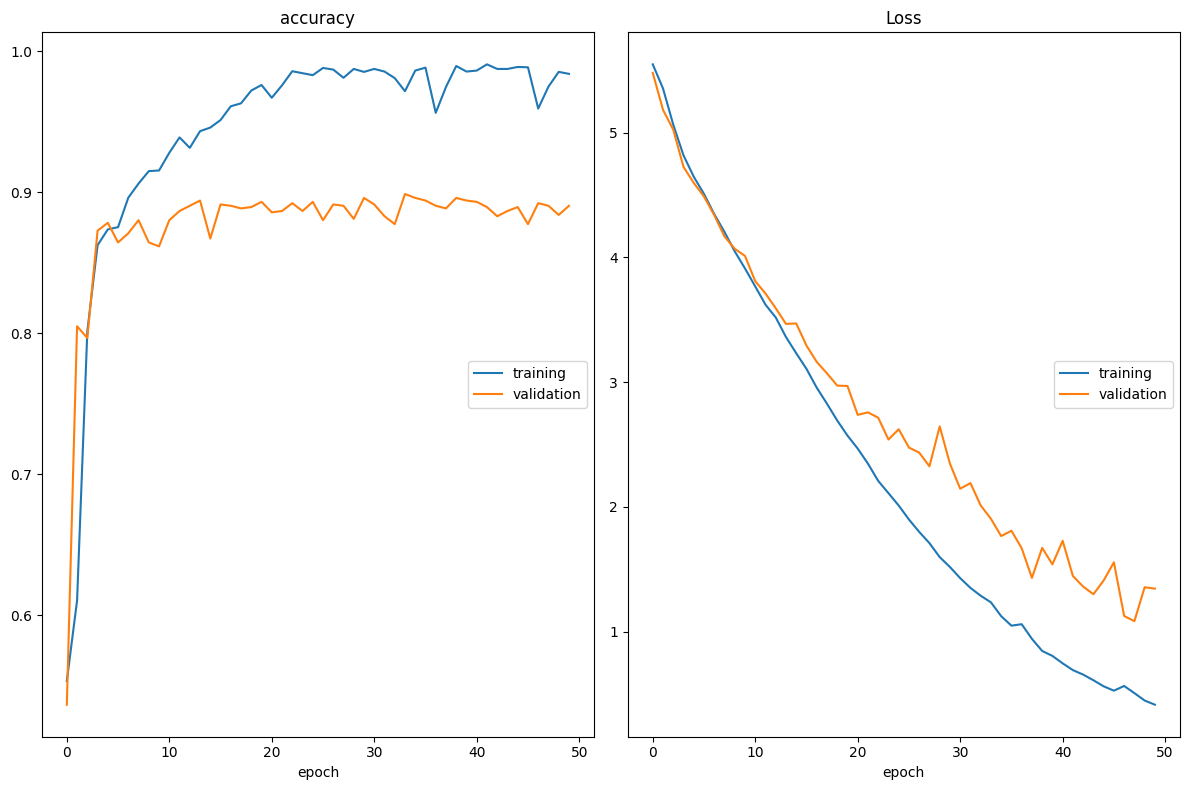

accuracy
	training         	 (min:    0.553, max:    0.991, cur:    0.984)
	validation       	 (min:    0.537, max:    0.899, cur:    0.890)
Loss
	training         	 (min:    0.414, max:    5.546, cur:    0.414)
	validation       	 (min:    1.083, max:    5.478, cur:    1.344)
68/68 [==============================] - 96s 1s/step - loss: 0.4136 - accuracy: 0.9840 - val_loss: 1.3441 - val_accuracy: 0.8904


In [ ]:
# Train the model
history = bayesian_model_scratch.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=[ckpt_bayesian, PlotLossesKeras(), early_stop_bayesian]
)

In [ ]:
def import_and_predict_bayes(image_path, true_label, labels, bayesian_model_scratch):
    # Read image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (64, 64))  # Ensure the image is 64x64
    img = img / 255.0  # Normalize the image
    img = np.expand_dims(img, axis=-1)  # Add channel dimension
    img = np.expand_dims(img, axis=0)  # Add batch dimension

    # Show the image
    plt.imshow(img[0, :, :, 0], cmap='gray')
    plt.axis('off')
    plt.show()

    # Initialize an array to store predicted probabilities
    predicted_probabilities = np.empty(shape=(300, 1))

    for i in range(300):
        prediction = bayesian_model_scratch.predict(img)
        predicted_probabilities[i] = prediction[0]

    # Calculate percentiles for predicted probabilities
    pct_2p5 = np.percentile(predicted_probabilities, 2.5)
    pct_97p5 = np.percentile(predicted_probabilities, 97.5)

    # Calculate entropy for each prediction
    entropies = -predicted_probabilities * np.log(predicted_probabilities) - (1 - predicted_probabilities) * np.log(1 - predicted_probabilities)

    # Calculate mean entropy
    mean_entropy = np.mean(entropies)
    print(f"Mean Entropy: {mean_entropy}")

    # Plot the results
    fig, ax = plt.subplots(figsize=(12, 6))
    bar = ax.bar([0, 1], [1 - pct_97p5, pct_97p5], color='red')
    bar[true_label].set_color('green')
    ax.bar([0, 1], [1 - pct_2p5, pct_2p5], color='white', alpha=0.5)  # Adjusted line
    ax.set_xticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_ylim([0, 1])
    ax.set_ylabel('Probability')
    plt.show()

    return predicted_probabilities

In [ ]:
# Define the image path
image_path = "/content/drive/MyDrive/SGA dataset/galaxy/augmented_IC3521-H01_1260_751_3_0_2302.jpg"
true_label = 1  # Example true label index for galaxy
labels = ['Galaxy', 'Star']  # Labels for the two classes

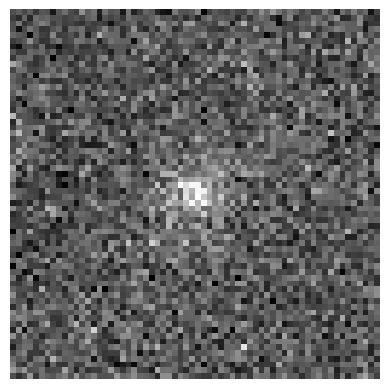

1/1 [==============================] - 0s 27ms/step
Mean Entropy: 0.0068138633355240745


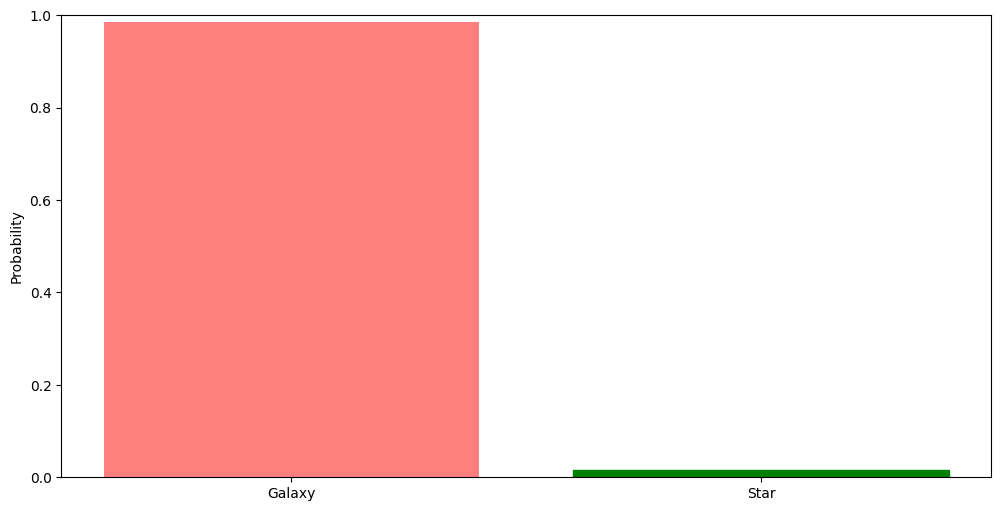

array([[9.39354052e-08],
       [1.07017502e-06],
       [1.69335712e-10],
       [3.74453846e-09],
       [1.13796510e-08],
       [1.91629988e-06],
       [4.05085281e-08],
       [7.65465380e-09],
       [2.62315166e-06],
       [7.64387220e-09],
       [8.80636564e-10],
       [7.95116222e-08],
       [1.08363027e-04],
       [9.27372545e-04],
       [2.77837175e-09],
       [3.74010050e-08],
       [9.97584149e-09],
       [2.49773264e-02],
       [6.01345819e-05],
       [1.74726556e-05],
       [3.30674593e-05],
       [3.52509378e-05],
       [2.11724882e-09],
       [5.58828678e-11],
       [1.54369986e-02],
       [5.57074342e-09],
       [1.52763544e-08],
       [3.54721233e-05],
       [3.38541306e-09],
       [9.90688818e-07],
       [7.89634669e-08],
       [1.16368977e-08],
       [6.66218984e-04],
       [5.86589507e-04],
       [7.99784907e-14],
       [2.15289813e-08],
       [2.60594097e-04],
       [5.71447067e-08],
       [3.74599097e-07],
       [1.44847967e-10],


In [ ]:
# Call the function with pre-loaded image data
import_and_predict_bayes(image_path, true_label, labels,bayesian_model_scratch)


In [ ]:
def print_mean_entropy(predicted_probabilities):
    # Calculate entropy for each prediction
    entropies = [-np.sum(p * np.log(p + 1e-10)) for p in predicted_probabilities]
    # Compute the mean entropy
    mean_entropy = np.mean(entropies)
    # Print the mean entropy
    print(f"Mean Entropy: {mean_entropy:.4f}")

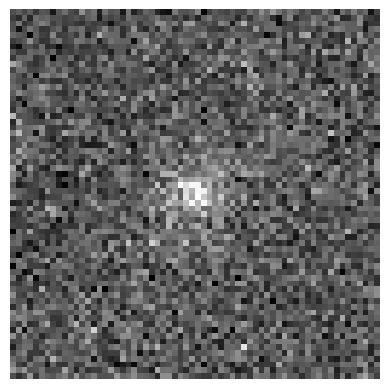

1/1 [==============================] - 0s 28ms/step
Mean Entropy: 0.01236368837601856


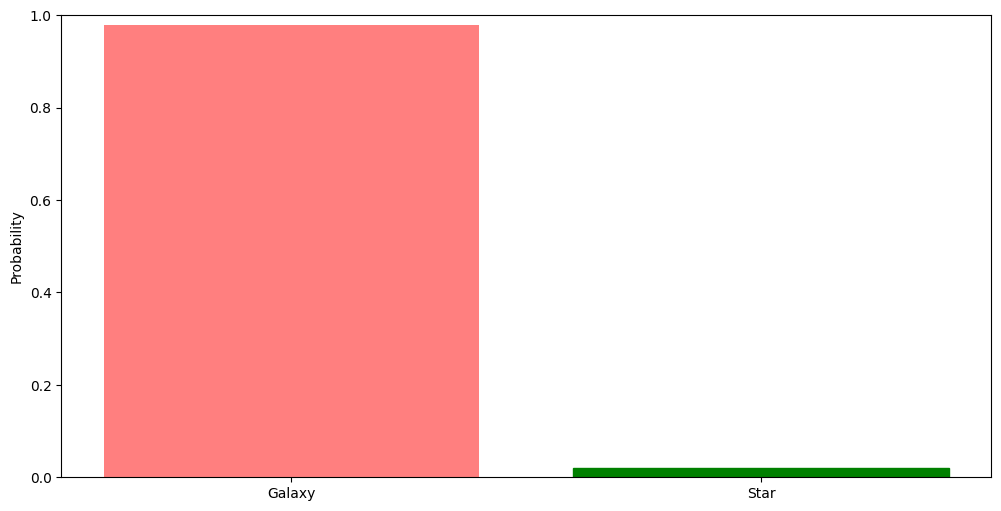

In [ ]:
# Call the function with pre-loaded image data
predicted_probabilities = import_and_predict_bayes(image_path, true_label, labels, bayesian_model_scratch)


In [ ]:
# Call the function to print mean entropy
print_mean_entropy(predicted_probabilities)

Mean Entropy: 0.0079


# **Testing with Aesteroid image**

In [ ]:
image_path1 = "/content/drive/MyDrive/SGA dataset/astroid2/000.jpg"

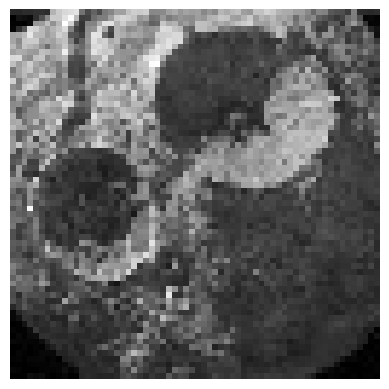

1/1 [==============================] - 0s 43ms/step
Mean Entropy: 0.5828303967330648


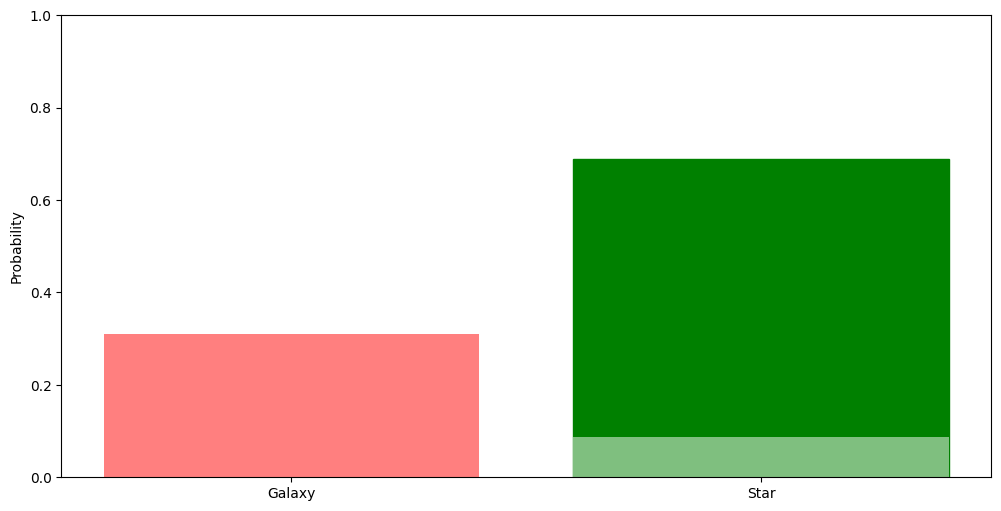

In [ ]:
# Call the function with pre-loaded image data
predicted_probabilities = import_and_predict_bayes(image_path1, true_label, labels, bayesian_model_scratch)

In [ ]:
# Call the function to print mean entropy
print_mean_entropy(predicted_probabilities)

Mean Entropy: 0.3291
